<a href="https://colab.research.google.com/github/praneshnikhar/Deep-Learning-models/blob/main/Univariate_Time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten


In [5]:
def prepare_data(timeseries_data, n_features):
  X,y = [],[]

  for i in range(len(timeseries_data)):
    end_ix = i+n_features
    if end_ix >len(timeseries_data)-1:
      break;
    seq_x, seq_y = timeseries_data[i:end_ix], timeseries_data[end_ix]
    X.append(seq_x)
    y.append(seq_y)
  return np.array(X), np.array(y)

In [7]:
timeseries_data = [110, 125, 133, 146, 158, 172, 187, 196,210]
n_features = 3

X,y = prepare_data(timeseries_data, n_features)

In [8]:
print(X), print(y)

[[110 125 133]
 [125 133 146]
 [133 146 158]
 [146 158 172]
 [158 172 187]
 [172 187 196]]
[146 158 172 187 196 210]


(None, None)

In [9]:
X.shape

(6, 3)

In [11]:
n_features = 1
X = X.reshape((X.shape[0],X.shape[1],n_features))

In [13]:
model = Sequential()
model.add(LSTM(50 , activation = 'relu', return_sequences=True, input_shape=(n_features,n_features)))
model.add(LSTM(50, activation = 'relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X,y, epochs=300, verbose=0)


In [15]:
import numpy as np

x_input = np.array([187, 196, 210])
temp_input = list(x_input)
lst_output = []
i = 0

while i < 10:
    if len(temp_input) > 3:
        x_input = np.array(temp_input[1:])
        x_input = x_input.reshape((1, -1))  # Assuming input shape is (1, n_features)
        yhat = model.predict(x_input, verbose=0)
        print("{} day input {}".format(i, yhat))
        temp_input.append(yhat[0][0])
        temp_input = temp_input[1:]
        lst_output.append(yhat[0][0])
    else:
        x_input = x_input.reshape((1, -1))  # Ensures it has the correct shape
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.append(yhat[0][0])
        lst_output.append(yhat[0][0])
    i += 1

print(lst_output)


[229.55858]
1 day input [[242.64749]]
2 day input [[261.07004]]
3 day input [[281.40283]]
4 day input [[299.20187]]
5 day input [[321.4893]]
6 day input [[344.43762]]
7 day input [[367.32343]]
8 day input [[393.76587]]
9 day input [[420.82523]]
[np.float32(229.55858), np.float32(242.64749), np.float32(261.07004), np.float32(281.40283), np.float32(299.20187), np.float32(321.4893), np.float32(344.43762), np.float32(367.32343), np.float32(393.76587), np.float32(420.82523)]


In [16]:
timeseries_data

[110, 125, 133, 146, 158, 172, 187, 196, 210]

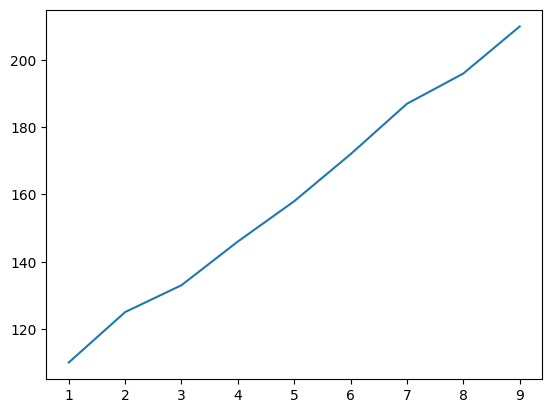

In [17]:
import matplotlib.pyplot as plt

day_new = np.arange(1,10)
day_pred = np.arange(10,20)

plt.plot(day_new,timeseries_data)

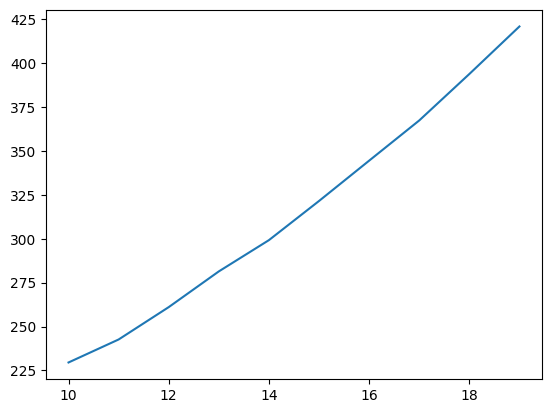

In [19]:
plt.plot(day_pred,lst_output)